In [1]:
# Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [2]:
# Chargement des données
df_customers = pd.read_csv('../donnees/brutes/olist_customers_dataset.csv')
df_orders = pd.read_csv('../donnees/brutes/olist_orders_dataset.csv')
df_payments = pd.read_csv('../donnees/brutes/olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('../donnees/brutes/olist_order_reviews_dataset.csv')

In [3]:
# Exploration de df_customers
print("=== CUSTOMERS ===")
print("Dimensions :", df_customers.shape)
print("\nColonnes :", df_customers.columns.tolist())
print("\nAperçu :")
df_customers.head()

=== CUSTOMERS ===
Dimensions : (99441, 5)

Colonnes : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Aperçu :


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
# Exploration de df_orders
print("=== ORDERS ===")
print("Dimensions :", df_orders.shape)
print("\nColonnes :", df_orders.columns.tolist())
print("\nAperçu :")
df_orders.head()

=== ORDERS ===
Dimensions : (99441, 8)

Colonnes : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Aperçu :


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
# Exploration de df_payments
print("=== PAYMENTS ===")
print("Dimensions :", df_payments.shape)
print("\nColonnes :", df_payments.columns.tolist())
print("\nAperçu :")
df_payments.head()

=== PAYMENTS ===
Dimensions : (103886, 5)

Colonnes : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Aperçu :


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
# Exploration de df_reviews
print("=== REVIEWS ===")
print("Dimensions :", df_reviews.shape)
print("\nColonnes :", df_reviews.columns.tolist())
print("\nAperçu :")
df_reviews.head()

=== REVIEWS ===
Dimensions : (99224, 7)

Colonnes : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Aperçu :


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
# Garder uniquement les colonnes utiles
df_customers = df_customers[['customer_id', 'customer_unique_id']]
df_orders = df_orders[['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp']]
df_payments = df_payments[['order_id', 'payment_value']]
df_reviews = df_reviews[['order_id', 'review_score']]

print("Colonnes filtrées avec succès ")

Colonnes filtrées avec succès 


In [8]:
# Vérification des valeurs manquantes
print("=== VALEURS MANQUANTES ===")
print("\nCustomers :")
print(df_customers.isnull().sum())
print("\nOrders :")
print(df_orders.isnull().sum())
print("\nPayments :")
print(df_payments.isnull().sum())
print("\nReviews :")
print(df_reviews.isnull().sum())

=== VALEURS MANQUANTES ===

Customers :
customer_id           0
customer_unique_id    0
dtype: int64

Orders :
order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
dtype: int64

Payments :
order_id         0
payment_value    0
dtype: int64

Reviews :
order_id        0
review_score    0
dtype: int64


In [9]:
# Vérification des doublons
print("=== DOUBLONS ===")
print("\nCustomers :", df_customers.duplicated().sum())
print("Orders :", df_orders.duplicated().sum())
print("Payments :", df_payments.duplicated().sum())
print("Reviews :", df_reviews.duplicated().sum())

=== DOUBLONS ===

Customers : 0
Orders : 0
Payments : 615
Reviews : 349


In [10]:
# Suppression des doublons
df_payments = df_payments.drop_duplicates()
df_reviews = df_reviews.drop_duplicates()

print("=== DOUBLONS APRES NETTOYAGE ===")
print("Payments :", df_payments.duplicated().sum())
print("Reviews :", df_reviews.duplicated().sum())

=== DOUBLONS APRES NETTOYAGE ===
Payments : 0
Reviews : 0


In [11]:
# Vérification des statuts de commandes
print("=== STATUTS DES COMMANDES ===")
print(df_orders['order_status'].value_counts())

=== STATUTS DES COMMANDES ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [12]:
# Garder uniquement les commandes livrées
df_orders = df_orders[df_orders['order_status'] == 'delivered']

print("=== APRES FILTRAGE ===")
print("Nombre de commandes :", df_orders.shape[0])

=== APRES FILTRAGE ===
Nombre de commandes : 96478


In [13]:
# Vérification des types de données
print("=== TYPES DE DONNEES ===")
print(df_orders.dtypes)

=== TYPES DE DONNEES ===
order_id                    str
customer_id                 str
order_status                str
order_purchase_timestamp    str
dtype: object


In [14]:
# Conversion de la date en type datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

print("=== TYPES APRES CONVERSION ===")
print(df_orders.dtypes)

=== TYPES APRES CONVERSION ===
order_id                               str
customer_id                            str
order_status                           str
order_purchase_timestamp    datetime64[us]
dtype: object


In [15]:
# Etape 1 — Fusionner orders et customers
df = df_orders.merge(df_customers, on='customer_id', how='left')

print("=== APRES FUSION ORDERS + CUSTOMERS ===")
print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())

=== APRES FUSION ORDERS + CUSTOMERS ===
Dimensions : (96478, 5)

Colonnes : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'customer_unique_id']


In [16]:
# Grouper les paiements avant fusion
df_payments_grouped = df_payments.groupby('order_id')['payment_value'].sum().reset_index()

In [17]:
# Etape 2 — Fusionner avec payments
df = df.merge(df_payments_grouped, on='order_id', how='left')

print("=== APRES FUSION + PAYMENTS ===")
print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())

=== APRES FUSION + PAYMENTS ===
Dimensions : (96478, 6)

Colonnes : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'customer_unique_id', 'payment_value']


In [18]:
# Regrouper les reviews par commande avant fusion
df_reviews_grouped = df_reviews.groupby('order_id')['review_score'].mean().reset_index()

In [19]:
# Etape 3 — Refaire la fusion avec reviews groupé
df = df_orders.merge(df_customers, on='customer_id', how='left')
df = df.merge(df_payments_grouped, on='order_id', how='left')
df = df.merge(df_reviews_grouped, on='order_id', how='left')

print("=== APRES FUSION COMPLETE ===")
print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())

=== APRES FUSION COMPLETE ===
Dimensions : (96478, 7)

Colonnes : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'customer_unique_id', 'payment_value', 'review_score']


In [20]:
# Apercu du jeu de données fusionné
print("=== APERCU DU JEU DE DONNEES ===")
print("Dimensions :", df.shape)
df.head(10)

=== APERCU DU JEU DE DONNEES ===
Dimensions : (96478, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,customer_unique_id,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,28.62,5.0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,80bb27c7c16e8f973207a5086ab329e2,175.26,4.0
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,932afa1e708222e5821dac9cd5db4cae,75.16,5.0
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,39382392765b6dc74812866ee5ee92a7,35.95,1.0
8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,299905e3934e9e181bfb2e164dd4b4f8,169.76,5.0
9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,f2a85dec752b8517b5e58a06ff3cd937,259.06,1.0


In [21]:
# Suppression de la colonne order_status
df = df.drop(columns=['order_status'])

print("Colonnes :", df.columns.tolist())

Colonnes : ['order_id', 'customer_id', 'order_purchase_timestamp', 'customer_unique_id', 'payment_value', 'review_score']


In [22]:
# Verification des valeurs manquantes
print("=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

=== VALEURS MANQUANTES ===
order_id                      0
customer_id                   0
order_purchase_timestamp      0
customer_unique_id            0
payment_value                 1
review_score                646
dtype: int64


In [23]:
# Afficher les lignes avec valeurs manquantes
print("payment_value manquant :")
print(df[df['payment_value'].isnull()])

print("\nreview_score manquant :", df['review_score'].isnull().sum())

payment_value manquant :
                               order_id                       customer_id  \
29811  bfbd0f9bdef84302105ad712db648a6c  86dc2ffce2dfff336de2f386a786e574   

      order_purchase_timestamp                customer_unique_id  \
29811      2016-09-15 12:16:38  830d5b7aaa3b6f1e9ad63703bec97d23   

       payment_value  review_score  
29811            NaN           1.0  

review_score manquant : 646


In [24]:
# Supprimer la ligne avec payment_value manquant
df = df.dropna(subset=['payment_value'])
print("Lignes apres suppression :", df.shape[0])

Lignes apres suppression : 96477


In [25]:
# Remplacer les valeurs manquantes de review_score par la moyenne
df['review_score'] = df['review_score'].fillna(df['review_score'].mean())
print("Valeurs manquantes apres nettoyage :")
print(df.isnull().sum())
print('salut')

Valeurs manquantes apres nettoyage :
order_id                    0
customer_id                 0
order_purchase_timestamp    0
customer_unique_id          0
payment_value               0
review_score                0
dtype: int64
salut


In [26]:
# Date de reference
date_reference = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Date de reference :", date_reference)

Date de reference : 2018-08-30 15:00:37


In [27]:
df_rfm = df.groupby('customer_unique_id').agg(
    recency = ('order_purchase_timestamp', lambda x: (date_reference - x.max()).days),
    frequency = ('order_id', 'count'),
    monetary = ('payment_value', 'sum'),
    satisfaction = ('review_score', 'mean')
).reset_index()

print("=== RFM ===")
print("Dimensions :", df_rfm.shape)
df_rfm.head(10)

=== RFM ===
Dimensions : (93357, 5)


,customer_unique_id,recency,frequency,monetary,satisfaction
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4.0
2,0000f46a3911fa3c0805444483337064,537,1,86.22,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,4.0
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,5.0
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4.0
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4.0
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,1.0
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,4.0
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,1.0


In [28]:
# Normalisation des données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_rfm_new = df_rfm[['recency', 'frequency', 'monetary', 'satisfaction']].copy()
df_rfm_new = pd.DataFrame(scaler.fit_transform(df_rfm_new), columns=['recency', 'frequency', 'monetary', 'satisfaction'])

print("=== APRES NORMALISATION ===")
df_rfm_new.head()

=== APRES NORMALISATION ===


,recency,frequency,monetary,satisfaction
0,-0.825362,-0.15983,-0.102177,0.663347
1,-0.805701,-0.15983,-0.609273,-0.120525
2,1.959998,-0.15983,-0.348321,-0.904398
3,0.544379,-0.15983,-0.536642,-0.120525
4,0.328104,-0.15983,0.140916,0.663347


print("pour df",df.columns)
print("pour df rfm", df_rfm.columns)
print("pour df rfm new", df_rfm_new)

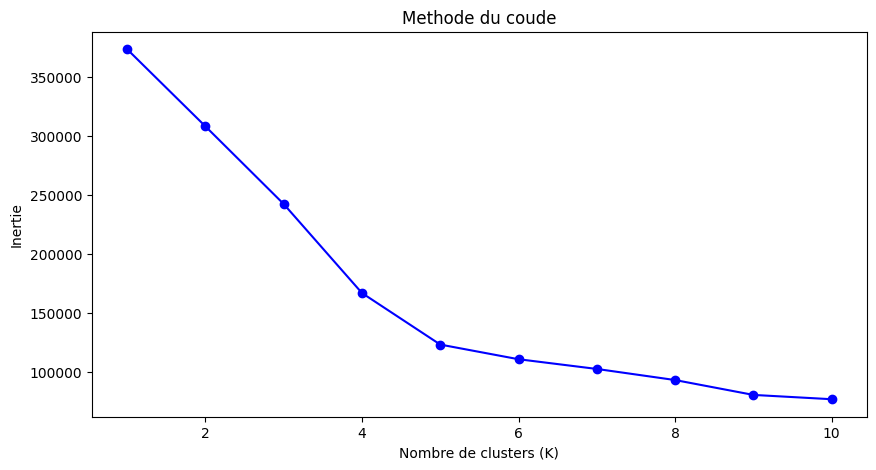

In [29]:
from sklearn.cluster import KMeans

inerties = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_rfm_new)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inerties, 'bo-')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie')
plt.title('Methode du coude')
plt.show()

In [30]:
# Etape 10 — Appliquer K-Means avec K=5
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_rfm_new)

# Ajouter les segments au tableau RFM
df_rfm['segment'] = kmeans.labels_

print("=== SEGMENTS ==")
print(df_rfm['segment'].value_counts())
df_rfm.head(10)

=== SEGMENTS ==
segment
1    41430
0    31485
2    15643
3     2772
4     2027
Name: count, dtype: int64


,customer_unique_id,recency,frequency,monetary,satisfaction,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4.0,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,3.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,4.0,0
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,5.0,0
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4.0,1
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4.0,1
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,1.0,2
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,4.0,0
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,1.0,2


In [31]:
# Analyser chaque segment
print(df_rfm.groupby('segment')[['recency', 'frequency', 'monetary', 'satisfaction']].mean().round(2))

         recency  frequency  monetary  satisfaction
segment                                            
0         394.01       1.00    133.98          4.64
1         123.31       1.00    132.76          4.70
2         230.75       1.00    150.46          1.73
3         220.44       2.11    289.21          4.21
4         235.89       1.02   1248.82          4.09


In [32]:
# Ajouter les noms des segments
noms_segments = {
    0: 'Inactifs',
    1: 'Nouveaux',
    2: 'Mécontents',
    3: 'Fidèles',
    4: 'Gros acheteurs'
}

df_rfm['segment_nom'] = df_rfm['segment'].map(noms_segments)

# Afficher les stats par segment avec les noms
print(df_rfm.groupby('segment_nom')[['recency', 'frequency', 'monetary', 'satisfaction']].mean().round(2))

                recency  frequency  monetary  satisfaction
segment_nom                                               
Fidèles          220.44       2.11    289.21          4.21
Gros acheteurs   235.89       1.02   1248.82          4.09
Inactifs         394.01       1.00    133.98          4.64
Mécontents       230.75       1.00    150.46          1.73
Nouveaux         123.31       1.00    132.76          4.70


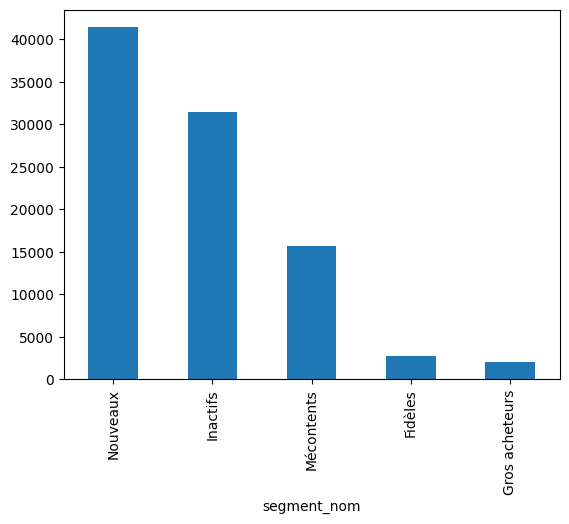

segment_nom
Nouveaux          41430
Inactifs          31485
Mécontents        15643
Fidèles            2772
Gros acheteurs     2027
Name: count, dtype: int64


['../sorties/modeles/kmeans_model.pkl']

In [33]:
import matplotlib.pyplot as plt

counts = df_rfm['segment_nom'].value_counts()
counts.plot(kind='bar')
plt.show()
print(counts)
joblib.dump(kmeans, '../sorties/modeles/kmeans_model.pkl')

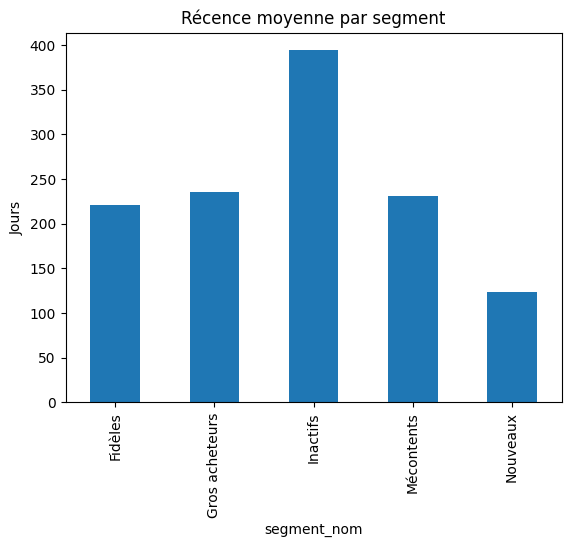

In [34]:
df_rfm.groupby('segment_nom')['recency'].mean().plot(kind='bar')
plt.title('Récence moyenne par segment')
plt.ylabel('Jours')
plt.show()

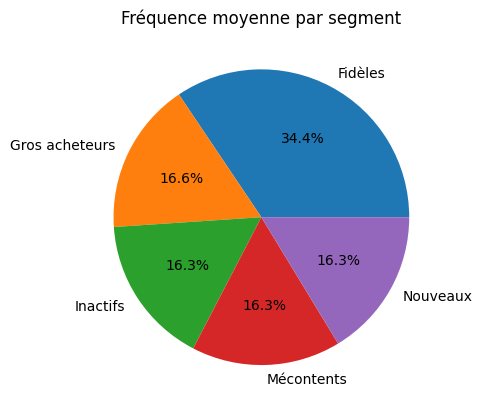

In [35]:
moyennes = df_rfm.groupby('segment_nom')['frequency'].mean().round(2)
moyennes.plot(kind='pie', autopct='%1.1f%%')
plt.title('Fréquence moyenne par segment')
plt.ylabel('')
plt.show()

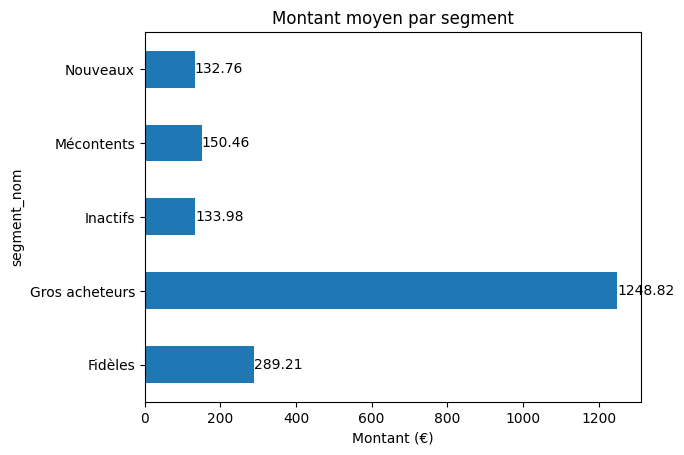

In [36]:
moyennes = df_rfm.groupby('segment_nom')['monetary'].mean().round(2)
moyennes.plot(kind='barh')
plt.title('Montant moyen par segment')
plt.xlabel('Montant (€)')

for i, v in enumerate(moyennes):
    plt.text(v, i, str(v), va='center')

plt.show()

In [37]:
# Sauvegarder df_rfm dans donnees/traitees
df_rfm.to_csv('../donnees/traitees/df_rfm.csv', index=False)
print("df_rfm sauvegardé avec succes !")

df_rfm sauvegardé avec succes !


In [38]:
# Stratégie de ciblage par segment
strategie = {
    'Inactifs': [
        "Email de relance : On vous manque !",
        "Offre promotionnelle limitée dans le temps",
        "Rappel des nouveaux produits"
    ],
    'Nouveaux': [
        "Offre -10% sur la prochaine commande valable 30 jours",
        "Suggestion de produits similaires à ceux achetés"
    ],
    'Mécontents': [
        "Email pour comprendre le problème",
        "Offrir un bon de réduction ou cadeau",
        "Assurer une meilleure expérience à la prochaine commande"
    ],
    'Fidèles': [
        "Programme de fidélité avec points de récompense",
        "Offres exclusives réservées aux clients fidèles",
        "Invitation aux ventes privées"
    ],
    'Gros acheteurs': [
        "Programme VIP avec accès exclusif aux nouveaux produits",
        "Livraison gratuite prioritaire",
        "Service client dédié"
    ]
}

for segment, actions in strategie.items():
    print(f"\n=== {segment} ===")
    for action in actions:
        print(f"  - {action}")


=== Inactifs ===
  - Email de relance : On vous manque !
  - Offre promotionnelle limitée dans le temps
  - Rappel des nouveaux produits

=== Nouveaux ===
  - Offre -10% sur la prochaine commande valable 30 jours
  - Suggestion de produits similaires à ceux achetés

=== Mécontents ===
  - Email pour comprendre le problème
  - Offrir un bon de réduction ou cadeau
  - Assurer une meilleure expérience à la prochaine commande

=== Fidèles ===
  - Programme de fidélité avec points de récompense
  - Offres exclusives réservées aux clients fidèles
  - Invitation aux ventes privées

=== Gros acheteurs ===
  - Programme VIP avec accès exclusif aux nouveaux produits
  - Livraison gratuite prioritaire
  - Service client dédié


In [39]:
import pandas as pd

data = {
    'Segment': ['🔴 Inactifs', '🟢 Nouveaux', '😡 Mécontents', '⭐ Fidèles', '💎 Gros acheteurs'],
    'Recency': ['394 jours', '123 jours', '230 jours', '220 jours', '235 jours'],
    'Frequency': ['1 achat', '1 achat', '1 achat', '2 achats', '1 achat'],
    'Monetary': ['133€', '132€', '150€', '289€', '1248€'],
    'Satisfaction': ['4.64 ⭐', '4.70 ⭐', '1.73 ⭐', '4.21 ⭐', '4.09 ⭐'],
    'Strategie': [
        '📧 Email relance + Promo limitée',
        '🎁 -10% prochaine commande + Produits similaires',
        '🤝 Comprendre problème + Bon cadeau',
        '🏆 Programme fidélité + Ventes privées',
        '👑 Programme VIP + Livraison prioritaire'
    ]
}

df_strategie = pd.DataFrame(data)
df_strategie.style.set_properties(**{
    'text-align': 'center',
    'font-size': '13px',
    'border': '1px solid black'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-size', '14px')]
}])

,Segment,Recency,Frequency,Monetary,Satisfaction,Strategie
0,🔴 Inactifs,394 jours,1 achat,133€,4.64 ⭐,📧 Email relance + Promo limitée
1,🟢 Nouveaux,123 jours,1 achat,132€,4.70 ⭐,🎁 -10% prochaine commande + Produits similaires
2,😡 Mécontents,230 jours,1 achat,150€,1.73 ⭐,🤝 Comprendre problème + Bon cadeau
3,⭐ Fidèles,220 jours,2 achats,289€,4.21 ⭐,🏆 Programme fidélité + Ventes privées
4,💎 Gros acheteurs,235 jours,1 achat,1248€,4.09 ⭐,👑 Programme VIP + Livraison prioritaire
